In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
import pandas as pd
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, Input
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:

df = pd.read_csv('/content/train_data_chatbot.csv')

questions = []
answers = []
for row in df.itertuples():
    _,ques,ans,_,_=row
    questions.append(ques)
    answers.append(ans)
print(len(questions))

47603


In [ ]:
print(df)
print(df.columns)

                                          short_question  \
0      can an antibiotic through an iv give you a ras...   
1      can you test positive from having the hep b va...   
2      what are the dietary restrictions for celiac d...   
3      can i transmit genital warts seventeen years a...   
4                              is all vitamin d the same   
...                                                  ...   
47598  what are north carolina is insurance plans for...   
47599   is garcinia mangostana safe to take with crestor   
47600           can ringworm virus give someone shingles   
47601  is the pneumococcal vaccine safe for pregnant ...   
47602  what is an angiotensin ii receptor blocker arb...   

                                            short_answer  \
0      yes it can even after you have finished the pr...   
1      test positive for what if you had a hep b vacc...   
2      omitting gluten from the diet is the key to co...   
3      famotidine pepcid products is in

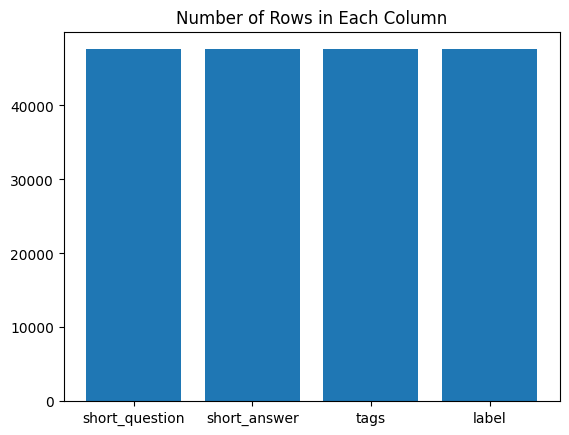

In [ ]:

import matplotlib.pyplot as plt

# Get the number of rows in the DataFrame
num_rows = len(df)

# Get the number of columns in the DataFrame
num_cols = len(df.columns)

# Create a figure with a single subplot
fig, ax = plt.subplots(1, 1)

# Create a bar chart with the number of rows for each column
ax.bar(df.columns, num_rows)

# Set the title of the chart
ax.set_title("Number of Rows in Each Column")

# Show the chart
plt.show()


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Assuming the DataFrame 'df' is already loaded and preprocessed
tags_list = df['tags'].str.lower().tolist()  # List of tags in lowercase
questions = df['short_question'].tolist()    # List of questions
answers = df['short_answer'].tolist()        # List of answers

# Create a dictionary for quick lookup of answers by tags
qa_dict = dict(zip(tags_list, answers))
questions_dict = dict(zip(questions, answers))

# Initialize TF-IDF Vectorizer for tags
vectorizer_tags = TfidfVectorizer()
# Fit and transform the tags list
tfidf_matrix_tags = vectorizer_tags.fit_transform(tags_list)

# Initialize TF-IDF Vectorizer for questions
vectorizer_questions = TfidfVectorizer()
# Fit and transform the questions list
tfidf_matrix_questions = vectorizer_questions.fit_transform(questions)

# Define the matching function
def get_best_match(query, tfidf_matrix_tags, tfidf_matrix_questions, tags_list, questions_list):
    query_vec_tags = vectorizer_tags.transform([query])
    query_vec_questions = vectorizer_questions.transform([query])

    similarity_scores_tags = cosine_similarity(query_vec_tags, tfidf_matrix_tags)
    similarity_scores_questions = cosine_similarity(query_vec_questions, tfidf_matrix_questions)

    best_match_index_tags = similarity_scores_tags.argmax()
    best_match_index_questions = similarity_scores_questions.argmax()

    best_match_score_tags = similarity_scores_tags[0, best_match_index_tags]
    best_match_score_questions = similarity_scores_questions[0, best_match_index_questions]

    if best_match_score_tags > best_match_score_questions:
        if best_match_score_tags > 0.5:
            return 'tag', tags_list[best_match_index_tags]
    else:
        if best_match_score_questions > 0.5:
            return 'question', questions_list[best_match_index_questions]

    return None, None
# def get_best_match(query, tfidf_matrix, tags_list):
#     # Transform the query using the same vectorizer
#     query_vec = vectorizer.transform([query])

#     # Compute cosine similarity between the query and the tags list
#     similarity_scores = cosine_similarity(query_vec, tfidf_matrix)

#     # Get the index of the most similar tag
#     best_match_index = similarity_scores.argmax()

#     # Check if the highest similarity score is significant enough (e.g., >0.1)
#     if similarity_scores[0, best_match_index] > 0.5:
#         return tags_list[best_match_index]
#     else:
#         return None

In [ ]:

def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r"i'm", "i am", txt)
    txt = re.sub(r"he's", "he is", txt)
    txt = re.sub(r"she's", "she is", txt)
    txt = re.sub(r"that's", "that is", txt)
    txt = re.sub(r"what's", "what is", txt)
    txt = re.sub(r"where's", "where is", txt)
    txt = re.sub(r"\'ll", " will", txt)
    txt = re.sub(r"\'ve", " have", txt)
    txt = re.sub(r"\'re", " are", txt)
    txt = re.sub(r"\'d", " would", txt)
    txt = re.sub(r"won't", "will not", txt)
    txt = re.sub(r"can't", "can not", txt)
    txt = re.sub(r"[^\w\s]", "", txt)
    return txt

# Assuming 'questions' and 'answers' are already defined
# Filtering questions and answers with length less than 30 and no duplicates
sorted_ques, sorted_ans = [], []
exist = {}
for i in range(len(questions)):
    if len(questions[i]) < 30 and questions[i] not in exist:
        exist[questions[i]] = True
        sorted_ques.append(questions[i])
        sorted_ans.append(answers[i])

# Clean the text data
clean_ques = [clean_text(q) for q in sorted_ques]
clean_ans = [' '.join(clean_text(a).split()[:28]) for a in sorted_ans]

# Build vocabulary of words with their counts
word2count = {}
for line in clean_ques + clean_ans:
    for word in line.split():
        word2count[word] = word2count.get(word, 0) + 1

# Create a vocabulary dictionary
vocab = {}
word_num = 0
for word, count in word2count.items():
    vocab[word] = word_num
    word_num += 1

# Add special tokens to the vocabulary
tokens = ['<PAD>', '<EOS>', '<OUT>', '<SOS>']
for token in tokens:
    vocab[token] = word_num
    word_num += 1

# Example of token swap (specific to dataset)
vocab['cameron'] = vocab['<PAD>']
vocab['<PAD>'] = 0

# Create inverse vocabulary for decoding
inv_vocab = {v: k for k, v in vocab.items()}

# Add start and end tokens to answers
clean_ans = ['<SOS> ' + ans + ' <EOS>' for ans in clean_ans]

# Convert words to their respective token ids
def convert_to_tokens(data, vocab):
    tokens = []
    for line in data:
        lst = [vocab.get(word, vocab['<OUT>']) for word in line.split()]
        tokens.append(lst)
    return tokens

encoder_inp = convert_to_tokens(clean_ques, vocab)
decoder_inp = convert_to_tokens(clean_ans, vocab)

# Pad sequences to ensure uniform length
encoder_inp = pad_sequences(encoder_inp, 30, padding='post', truncating='post')
decoder_inp = pad_sequences(decoder_inp, 30, padding='post', truncating='post')

# Prepare decoder output by shifting the input sequence to the right
decoder_final_output = pad_sequences([i[1:] for i in decoder_inp], 30, padding='post', truncating='post')

# Convert the decoder output to one-hot encoded vectors
decoder_final_output = to_categorical(decoder_final_output, len(vocab))

# Print shape of the final decoder output for verification
print(decoder_final_output.shape)


(865, 30, 4164)


In [ ]:
!pip install nltk


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:

# Lowercase the text
clean_ques = [q.lower() for q in clean_ques]
clean_ans = [a.lower() for a in clean_ans]

# Remove punctuation
import string
clean_ques = [''.join(c for c in q if c not in string.punctuation) for q in clean_ques]
clean_ans = [''.join(c for c in a if c not in string.punctuation) for a in clean_ans]

# Remove stop words
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
clean_ques = [' '.join(word for word in q.split() if word not in stop_words) for q in clean_ques]
clean_ans = [' '.join(word for word in a.split() if word not in stop_words) for a in clean_ans]

# Convert words to their respective token ids
encoder_inp = convert_to_tokens(clean_ques, vocab)
decoder_inp = convert_to_tokens(clean_ans, vocab)

# Pad sequences to ensure uniform length
encoder_inp = pad_sequences(encoder_inp, 30, padding='post', truncating='post')
decoder_inp = pad_sequences(decoder_inp, 30, padding='post', truncating='post')

# Prepare decoder output by shifting the input sequence to the right
decoder_final_output = pad_sequences([i[1:] for i in decoder_inp], 30, padding='post', truncating='post')

# Convert the decoder output to one-hot encoded vectors
decoder_final_output = to_categorical(decoder_final_output, len(vocab))


In [ ]:
# Define input placeholders for encoder and decoder inputs
enc_inp = Input(shape=(30, ))  # Encoder input of shape (30, )
dec_inp = Input(shape=(30, ))  # Decoder input of shape (30, )

# Define vocabulary size
VOCAB_SIZE = len(vocab)

# Embedding layer
embed = Embedding(VOCAB_SIZE + 1,  # Vocabulary size plus 1
                  output_dim=50,  # Embedding output dimension
                  input_length=30,  # Input length
                  trainable=True)  # Embedding layer is trainable

# Encoder embedding
enc_embed = embed(enc_inp)

# Encoder LSTM
enc_lstm = LSTM(400, return_sequences=True, return_state=True)
# Get the encoder outputs and states
enc_op, h, c = enc_lstm(enc_embed)
enc_states = [h, c]  # Store encoder states

# Decoder embedding
dec_embed = embed(dec_inp)

# Decoder LSTM
dec_lstm = LSTM(400, return_sequences=True, return_state=True)
# Get the decoder outputs
dec_op, _, _ = dec_lstm(dec_embed, initial_state=enc_states)

# Dense layer for final output
dense = Dense(VOCAB_SIZE, activation='softmax')
# Apply dense layer to the decoder output
dense_op = dense(dec_op)

# Define the model with encoder and decoder inputs and final output
model = Model([enc_inp, dec_inp], dense_op)

# Compile the model with categorical crossentropy loss, accuracy metric, and Adam optimizer
model.compile(loss='categorical_crossentropy', metrics=['acc'], optimizer='adam')

# Print the model summary
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 30)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer (InputLayer)  │ (None, 30)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 30, 50)         │        208,250 │ input_layer[0][0],     │
│                           │                        │                │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, 30, 400),      │        721,600 │ embedding[0][0]        │
│                           │ (None, 400), (None,    │                │                        │
│                           │ 400)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ [(None, 30, 400),      │        721,600 │ embedding[1][0],       │
│                           │ (None, 400), (None,    │                │ lstm[0][1], lstm[0][2] │
│                           │ 400)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 30, 4164)       │      1,669,764 │ lstm_1[0][0]           │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,321,214 (12.67 MB)

 Trainable params: 3,321,214 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit([encoder_inp, decoder_inp], decoder_final_output, epochs=180)


Epoch 1/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - acc: 0.4270 - loss: 6.5374
Epoch 2/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.4985 - loss: 3.9038
Epoch 3/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5072 - loss: 3.7101
Epoch 4/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5228 - loss: 3.6288
Epoch 5/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5360 - loss: 3.5590
Epoch 6/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5375 - loss: 3.5122
Epoch 7/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5338 - loss: 3.5105
Epoch 8/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5315 - loss: 3.4993
Epoch 9/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.5291 - loss: 3.4926
Epoch 10/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.5378 - loss: 3.4089
Epoch 11/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.5393 - loss: 3.3767
Epoch 12/250
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - acc: 0.5363 - loss: 3.3694
Epoch 13/250
28/28 ━━━━━━

In [ ]:
# prompt: validation accuracy

val_acc = model.evaluate([encoder_inp, decoder_inp], decoder_final_output)
print("Validation accuracy:", val_acc[1])


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9713 - loss: 0.1438
Validation accuracy: 0.9710596203804016


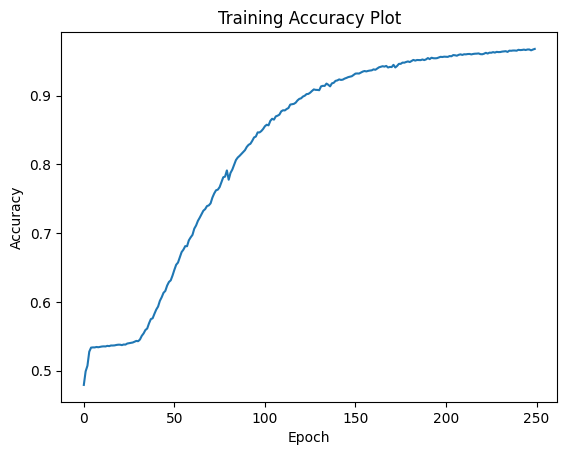

In [ ]:
import matplotlib.pyplot as plt

# Get the train accuracy from the history object
train_accuracy = history.history['acc']

# Create a plot
plt.plot(train_accuracy, label='Training Accuracy')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Plot')

# Show the plot
plt.show()


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input


enc_model = Model([enc_inp], enc_states)



# decoder Model
decoder_state_input_h = Input(shape=(400,))
decoder_state_input_c = Input(shape=(400,))

decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]


decoder_outputs, state_h, state_c = dec_lstm(dec_embed ,
                                    initial_state=decoder_states_inputs)


decoder_states = [state_h, state_c]


dec_model = Model([dec_inp]+ decoder_states_inputs,
                                      [decoder_outputs]+ decoder_states)

In [ ]:
def chatbot(tfidf_matrix_tags, tfidf_matrix_questions, tags_list, questions_list):  # Added parameters to the chatbot function
    print("Welcome to the chatbot! Ask your questions or type 'exit' to leave.")

    while True:
        user_input = input("You: ").strip().lower()

        if user_input == "exit":
            print("Chatbot: Goodbye!")
            break

        match_type, best_match = get_best_match(user_input, tfidf_matrix_tags, tfidf_matrix_questions, tags_list, questions_list)

        if match_type == 'tag':
            answer = qa_dict[best_match]  # Changed variable name to qa_dict
        elif match_type == 'question':
            answer = questions_dict[best_match]  # Changed variable name to questions_dict
        else:
            answer = "Sorry, I don't have an answer for that."

        print(f"Chatbot: {answer}")

# Run the chatbot
chatbot(tfidf_matrix_tags, tfidf_matrix_questions, tags_list, questions)


Welcome to the chatbot! Ask your questions or type 'exit' to leave.
You: when should the doctor be called for diarrhea
Chatbot: okay so type 1 is common to oral area and type 2 is common to genital area you just have type 1 on your genitals it will not turn into type 2 your test will always come back positive for type 1 no matter where on your body it shows up typical outbreaks happen during stressful or extra moist for prolong periods of time herpes outbreaks will become less frequent the longer you have had it your partner is always at risk whether you have an active outbreak or not <negative_smiley> you can pass it days before you notice an outbreak be honest with your partner   as you know this is a life long disease always let your obgyn know when you decide to have a baby they will give you a daily supressive med to keep from passing along to your child or you can opt for a c section good luck god bless and hope this helped
You: diarrhea
Chatbot: okay so type 1 is common to oral 